In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/merged_dataset_after_data_preprocessing.csv')

In [ ]:
print(df['TransactionDT'])

0         1970-01-02 00:01:46
1         1970-01-02 00:02:15
2         1970-01-02 00:02:29
3         1970-01-02 00:02:35
4         1970-01-02 00:03:40
                 ...         
144228    1970-07-02 23:53:22
144229    1970-07-02 23:54:36
144230    1970-07-02 23:55:12
144231    1970-07-02 23:55:35
144232    1970-07-02 23:57:10
Name: TransactionDT, Length: 144233, dtype: object


In [ ]:
df.shape

(144233, 613)

In [ ]:
print(df.isnull().any().sum())

352


In [ ]:
df = df.fillna(-1)

In [ ]:
drop_cols = ['TransactionID','TransactionDT']  # label not used for AE training
df_ae = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ae)

In [ ]:
# Use only non-fraud transactions
df_ae['isFraud'] = df_ae['isFraud'].astype(int)

X_train = X_scaled[df_ae['isFraud'] == 0]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_scaled.shape[1]  # should be 618

input_layer = layers.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(512, activation='relu')(input_layer)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)

bottleneck = layers.Dense(64, activation='relu')(x)

# Decoder
x = layers.Dense(128, activation='relu')(bottleneck)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.2)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)

output_layer = layers.Dense(input_dim, activation='linear')(x)

autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 612)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       313,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 612)            │       313,956 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,340 (3.73 MB)

 Trainable params: 975,780 (3.72 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=2048,   # large dataset → bigger batch
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 22s 281ms/step - loss: 0.3769 - val_loss: 1.9726
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - loss: 0.2195 - val_loss: 1.8299
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - loss: 0.1885 - val_loss: 1.7932
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 257ms/step - loss: 0.1691 - val_loss: 1.6205
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 255ms/step - loss: 0.1594 - val_loss: 1.5978
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - loss: 0.1482 - val_loss: 1.5317
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - loss: 0.1491 - val_loss: 1.5852
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 255ms/step - loss: 0.1364 - val_loss: 1.5191
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 284ms/step - loss: 0.1446 - val_loss: 1.5671
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - loss: 0.1305 - val_loss: 1.6338
Epoch 11/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 20s 262ms/step - loss: 0.1219 - val_loss: 1.4234
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 22

In [ ]:
# Predict reconstruction for ALL data (not just train)
X_pred = autoencoder.predict(X_scaled, batch_size=2048)

# Compute reconstruction error (MSE per row)
reconstruction_error = np.mean(
    np.power(X_scaled - X_pred, 2),
    axis=1
)

# Add AE score to dataset
df['ae_score'] = reconstruction_error

71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step


In [ ]:
df['ae_score'] = np.log1p(df['ae_score'])   # log transform (best)

In [ ]:
df['ae_score']

,ae_score
0,0.057046
1,0.053549
2,0.159989
3,0.052416
4,0.058955
...,...
144228,0.158498
144229,0.266277
144230,0.050265
144231,0.275497


In [ ]:
df['ae_bin'] = pd.qcut(df['ae_score'], q=10, duplicates='drop')

In [ ]:
fraud_analysis = df.groupby('ae_bin').agg(
    total_transactions=('isFraud', 'count'),
    fraud_cases=('isFraud', 'sum')
)

fraud_analysis['fraud_rate'] = fraud_analysis['fraud_cases'] / fraud_analysis['total_transactions']

print(fraud_analysis)

                  total_transactions  fraud_cases  fraud_rate
ae_bin                                                       
(0.0097, 0.0308]               14424            0    0.000000
(0.0308, 0.0383]               14423            1    0.000069
(0.0383, 0.0459]               14423           65    0.004507
(0.0459, 0.0546]               14423          233    0.016155
(0.0546, 0.0648]               14424          457    0.031683
(0.0648, 0.0781]               14423          719    0.049851
(0.0781, 0.0974]               14423          921    0.063856
(0.0974, 0.131]                14423         1377    0.095473
(0.131, 0.209]                 14423         2717    0.188380
(0.209, 8.176]                 14424         4828    0.334720


/tmp/ipykernel_12033/3360687117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_analysis = df.groupby('ae_bin').agg(


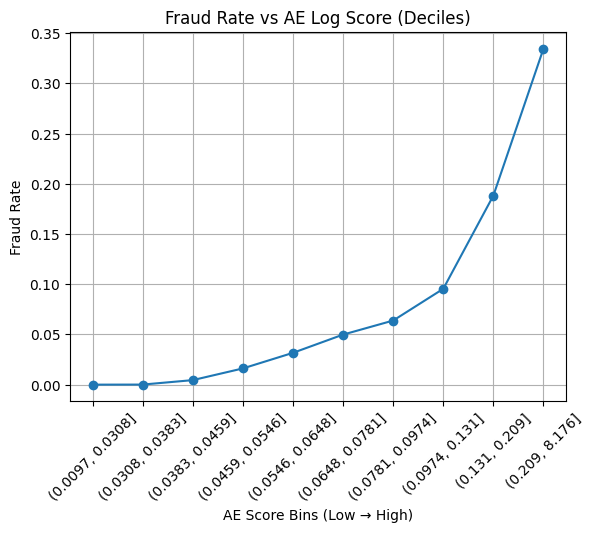

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fraud_analysis['fraud_rate'].values, marker='o')
plt.xticks(range(len(fraud_analysis)), fraud_analysis.index.astype(str), rotation=45)
plt.title("Fraud Rate vs AE Log Score (Deciles)")
plt.xlabel("AE Score Bins (Low → High)")
plt.ylabel("Fraud Rate")
plt.grid()
plt.show()

In [ ]:
df['ae_percentile'] = df['ae_score'].rank(pct=True)

In [ ]:
df['very_high_ae'] = (df['ae_percentile'] > 0.95).astype(int)

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

In [ ]:
df.to_csv("fraud_with_rules_and_ae.csv", index=False)